# Tesco Retail Productivity Analysis

## 1. Setup

In [25]:
# Import the libraries I'll need throughout this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean, consistent style for all charts
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

## 2. Load the Data

First look at the dataset - dimensions, columns, data types and whether anything is missing.

In [2]:
df = pd.read_csv('data/tesco_retail_data.csv')

print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn types:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')

Rows:    15,000
Columns: 12

Column types:
transaction_id         str
date                   str
store_location         str
customer_id            str
product_name           str
category               str
quantity             int64
unit_price         float64
total_amount       float64
status                 str
payment_method         str
clubcard_member        str
dtype: object

Missing values: 0


In [3]:
# First 5 rows to understand the structure
df.head()

,transaction_id,date,store_location,customer_id,product_name,category,quantity,unit_price,total_amount,status,payment_method,clubcard_member
0,TXN10709,2023-01-01,Stevenage,CUST0115,Free Range Eggs 6pk,Grocery,1,1.88,1.88,Fulfilled,Contactless,No
1,TXN12782,2023-01-01,Luton,CUST0372,Orange Squash 750ml,Drinks,2,1.30,2.60,Fulfilled,Contactless,Yes
2,TXN15445,2023-01-01,St Albans,CUST1737,Ice Cream Vanilla 2L,Frozen,1,3.49,3.49,Fulfilled,Card,No
3,TXN6198,2023-01-01,St Albans,CUST1558,Rice 1kg,Grocery,3,1.36,4.08,Fulfilled,Clubcard Pay+,Yes
4,TXN6117,2023-01-01,St Albans,CUST0737,Free Range Eggs 6pk,Grocery,1,1.86,1.86,Fulfilled,Card,No


In [4]:
# Basic statistics on numerical columns
df.describe().round(2)

,quantity,unit_price,total_amount
count,15000.00,15000.00,15000.00
mean,2.24,2.33,4.81
std,1.27,1.28,4.46
min,1.00,0.53,0.00
25%,1.00,1.32,1.90
50%,2.00,1.94,3.59
75%,3.00,3.05,6.38
max,6.00,7.20,35.95


In [26]:
# What values exist in each categorical column
for col in ['store_location', 'category', 'status', 'payment_method', 'clubcard_member']:
    print(f'\n- {col} -')
    print(df[col].value_counts().to_string())


- store_location -
store_location
Welwyn Garden City    3047
St Albans             2276
Hatfield              2264
Luton                 1860
Stevenage             1827
Watford               1485
Hemel Hempstead       1172
Hertford              1069

- category -
category
Grocery            3362
Fresh Produce      2439
Meat & Fish        1994
Drinks             1488
Frozen             1478
Bakery             1424
Health & Beauty    1413
Household          1402

- status -
status
Fulfilled    13882
Cancelled     1118

- payment_method -
payment_method
Contactless      5949
Card             5272
Clubcard Pay+    2267
Cash             1512

- clubcard_member -
clubcard_member
Yes    9761
No     5239


## 3. Clean and Prepare

The date column loads as plain text - I need to convert it to a proper datetime type so I can group by month, week, or quarter later.

In [6]:
# Convert date from string to datetime
df['date'] = pd.to_datetime(df['date'])

# Pull out the time dimensions I'll need for trend charts
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b')   # Jan, Feb, Mar...
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['quarter']     = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.day_name()

print('Date range:', df['date'].min().strftime('%d %b %Y'), 'to', df['date'].max().strftime('%d %b %Y'))
df[['date', 'month', 'month_name', 'week', 'quarter', 'day_of_week']].head(3)

Date range: 01 Jan 2023 to 31 Dec 2023


,date,month,month_name,week,quarter,day_of_week
0,2023-01-01,1,Jan,52,1,Sunday
1,2023-01-01,1,Jan,52,1,Sunday
2,2023-01-01,1,Jan,52,1,Sunday


In [7]:
# Split into fulfilled and cancelled — I'll use these separately throughout
# Revenue analysis only counts fulfilled orders
fulfilled_df = df[df['status'] == 'Fulfilled'].copy()
cancelled_df = df[df['status'] == 'Cancelled'].copy()

print(f'Total:     {len(df):,}')
print(f'Fulfilled: {len(fulfilled_df):,}  ({len(fulfilled_df)/len(df)*100:.1f}%)')
print(f'Cancelled: {len(cancelled_df):,}  ({len(cancelled_df)/len(df)*100:.1f}%)')

Total:     15,000
Fulfilled: 13,882  (92.5%)
Cancelled: 1,118  (7.5%)


## 4. Headline KPIs

Before breaking anything down I want the top-line numbers for the full year.

In [27]:
# Calculate the core KPIs
total_revenue     = fulfilled_df['total_amount'].sum()
total_txns        = df['transaction_id'].nunique()
fulfilled_count   = fulfilled_df['transaction_id'].nunique()
cancelled_count   = cancelled_df['transaction_id'].nunique()
cancellation_rate = cancelled_count / total_txns * 100
avg_order_value   = fulfilled_df['total_amount'].mean()
unique_customers  = df['customer_id'].nunique()

# Best and worst months
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_rev = fulfilled_df.groupby('month_name')['total_amount'].sum().reindex(month_order)
best_month  = monthly_rev.idxmax()
worst_month = monthly_rev.idxmin()

print('  TESCO NETWORK — 2023 FULL YEAR')
print(f'  Total Revenue:        GBP {total_revenue:>10,.2f}')
print(f'  Total Transactions:       {total_txns:>10,}')
print(f'  Fulfilled Orders:         {fulfilled_count:>10,}')
print(f'  Cancelled Orders:         {cancelled_count:>10,}')
print(f'  Cancellation Rate:        {cancellation_rate:>9.1f}%')
print(f'  Avg Order Value:      GBP {avg_order_value:>10.2f}')
print(f'  Unique Customers:         {unique_customers:>10,}')
print(f'  Peak Month:               {best_month:>10}  (GBP {monthly_rev[best_month]:,.0f})')
print(f'  Weakest Month:            {worst_month:>10}  (GBP {monthly_rev[worst_month]:,.0f})')

  TESCO NETWORK — 2023 FULL YEAR
  Total Revenue:        GBP  72,103.47
  Total Transactions:           15,000
  Fulfilled Orders:             13,882
  Cancelled Orders:              1,118
  Cancellation Rate:              7.5%
  Avg Order Value:      GBP       5.19
  Unique Customers:              2,982
  Peak Month:                      Dec  (GBP 6,516)
  Weakest Month:                   Feb  (GBP 5,361)


## 5. Revenue by Category

Which categories are driving the most revenue?

In [9]:
# Group fulfilled transactions by category and sum revenue
cat_rev = (
    fulfilled_df
    .groupby('category')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
cat_rev['share_pct'] = (cat_rev['total_amount'] / total_revenue * 100).round(1)

print('Revenue by Category:')
print(cat_rev.to_string(index=False))

Revenue by Category:
       category  total_amount  share_pct
    Meat & Fish      14656.37       20.3
        Grocery      11260.88       15.6
      Household      10591.65       14.7
         Drinks       8691.27       12.1
         Frozen       7711.65       10.7
Health & Beauty       7642.99       10.6
  Fresh Produce       6125.26        8.5
         Bakery       5423.40        7.5


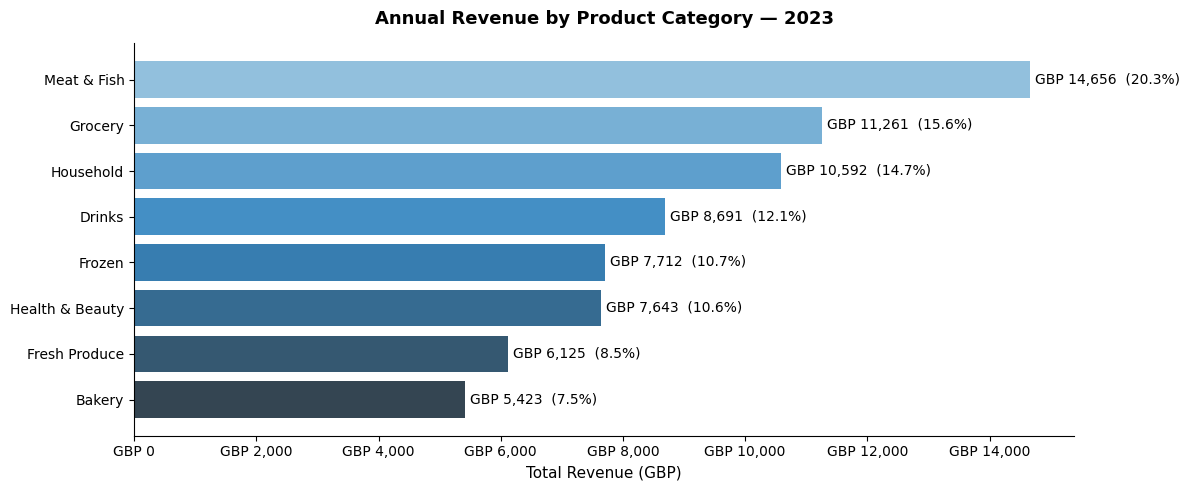

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.barh(
    cat_rev['category'],
    cat_rev['total_amount'],
    color=sns.color_palette('Blues_d', len(cat_rev))
)

# Add value labels at the end of each bar
for i, (val, pct) in enumerate(zip(cat_rev['total_amount'], cat_rev['share_pct'])):
    ax.text(val + 80, i, f'GBP {val:,.0f}  ({pct}%)', va='center', fontsize=10)

ax.set_xlabel('Total Revenue (GBP)', fontsize=11)
ax.set_title('Annual Revenue by Product Category — 2023', fontsize=13, fontweight='bold', pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Monthly Revenue Trend

How does revenue move across the year? I want to see the seasonal pattern clearly.

In [11]:
# Aggregate revenue by month, keeping the month number for correct sorting
monthly = (
    fulfilled_df
    .groupby(['month', 'month_name'])['total_amount']
    .sum()
    .reset_index()
    .sort_values('month')
)

# Month-on-month growth percentage
monthly['mom_growth'] = monthly['total_amount'].pct_change() * 100

print('Monthly Revenue:')
for _, row in monthly.iterrows():
    mom = f"{row['mom_growth']:+.1f}%" if not pd.isna(row['mom_growth']) else '  -'
    print(f"  {row['month_name']:>4}:  GBP {row['total_amount']:>8,.0f}   MoM: {mom}")

Monthly Revenue:
   Jan:  GBP    6,032   MoM:   -
   Feb:  GBP    5,361   MoM: -11.1%
   Mar:  GBP    5,889   MoM: +9.8%
   Apr:  GBP    5,873   MoM: -0.3%
   May:  GBP    6,196   MoM: +5.5%
   Jun:  GBP    5,867   MoM: -5.3%
   Jul:  GBP    6,118   MoM: +4.3%
   Aug:  GBP    6,346   MoM: +3.7%
   Sep:  GBP    5,851   MoM: -7.8%
   Oct:  GBP    6,326   MoM: +8.1%
   Nov:  GBP    5,729   MoM: -9.4%
   Dec:  GBP    6,516   MoM: +13.7%


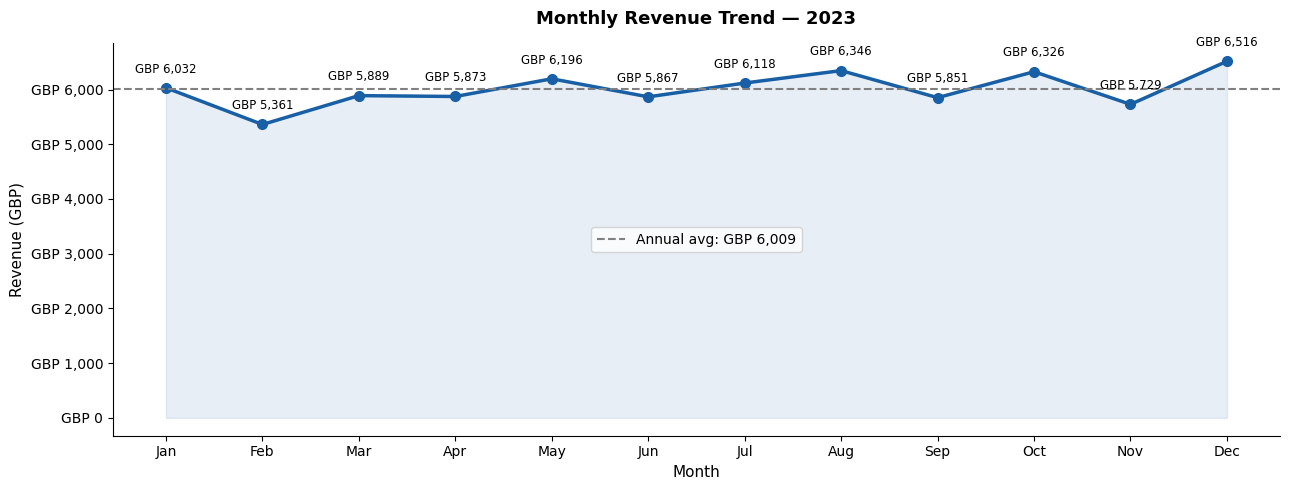

Peak-to-trough ratio: 1.22x


In [12]:
fig, ax = plt.subplots(figsize=(13, 5))

# Fill under the line to make the shape more readable
ax.fill_between(monthly['month_name'], monthly['total_amount'], alpha=0.1, color='#185FA5')
ax.plot(
    monthly['month_name'], monthly['total_amount'],
    color='#185FA5', linewidth=2.5, marker='o', markersize=7
)

# Annotate every data point with its value
for _, row in monthly.iterrows():
    ax.annotate(
        f"GBP {row['total_amount']:,.0f}",
        (row['month_name'], row['total_amount']),
        textcoords='offset points', xytext=(0, 11),
        ha='center', fontsize=8.5
    )

# Dashed reference line showing the annual average
ax.axhline(
    monthly['total_amount'].mean(),
    color='gray', linestyle='--', linewidth=1.5,
    label=f"Annual avg: GBP {monthly['total_amount'].mean():,.0f}"
)

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (GBP)', fontsize=11)
ax.set_title('Monthly Revenue Trend — 2023', fontsize=13, fontweight='bold', pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

ratio = monthly['total_amount'].max() / monthly['total_amount'].min()
print(f'Peak-to-trough ratio: {ratio:.2f}x')

## 7. Cancellation Analysis

Cancellations mean lost revenue and wasted operational effort. I want to know which categories and stores have the worst problem.

In [13]:
# Calculate cancel rate per category and estimate the revenue impact
cancel_cat = (
    df.groupby('category')
    .agg(
        total     = ('transaction_id', 'count'),
        cancelled = ('status', lambda x: (x == 'Cancelled').sum())
    )
    .reset_index()
)

# Estimate lost revenue using the average fulfilled order value per category
avg_val = fulfilled_df.groupby('category')['total_amount'].mean()
cancel_cat['cancel_rate']       = (cancel_cat['cancelled'] / cancel_cat['total'] * 100).round(1)
cancel_cat['est_lost_revenue']  = (cancel_cat['cancelled'] * avg_val).round(0)
cancel_cat = cancel_cat.sort_values('cancel_rate', ascending=False)

print('Cancellation by Category:')
print(cancel_cat.to_string(index=False))

Cancellation by Category:
       category  total  cancelled  cancel_rate  est_lost_revenue
Health & Beauty   1413        141         10.0               NaN
    Meat & Fish   1994        190          9.5               NaN
      Household   1402        123          8.8               NaN
         Frozen   1478        120          8.1               NaN
  Fresh Produce   2439        194          8.0               NaN
         Bakery   1424         85          6.0               NaN
        Grocery   3362        188          5.6               NaN
         Drinks   1488         77          5.2               NaN


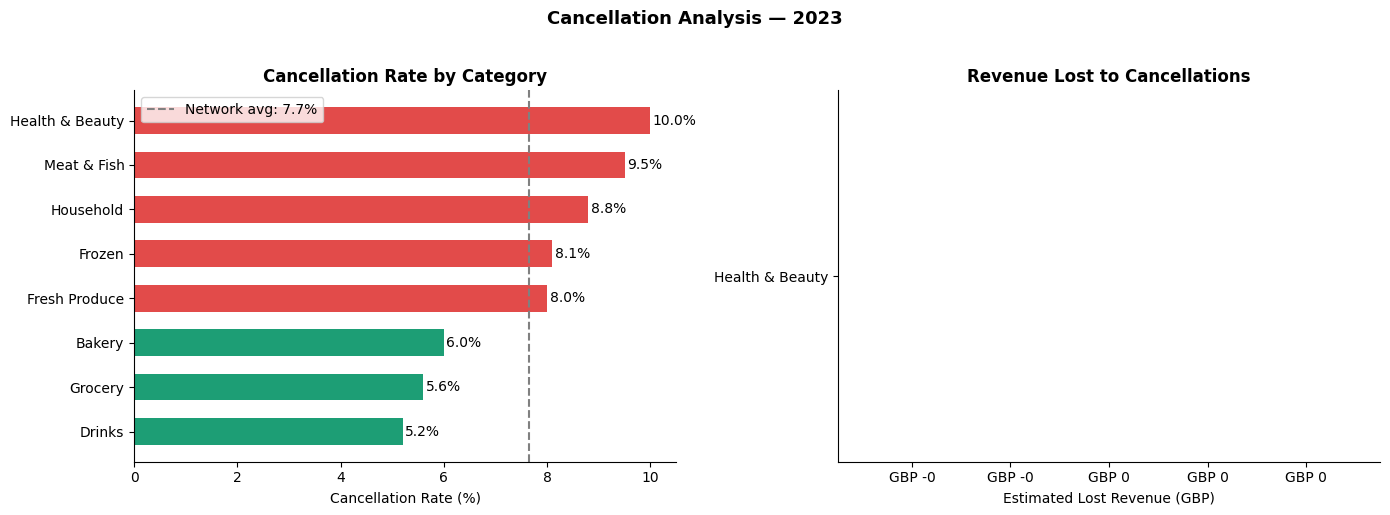

Total estimated revenue lost: GBP 0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_rate = cancel_cat['cancel_rate'].mean()

# Colour bars red if above average, green if below
colors = ['#E24B4A' if r > avg_rate else '#1D9E75' for r in cancel_cat['cancel_rate']]

# Left chart — cancel rate
axes[0].barh(cancel_cat['category'], cancel_cat['cancel_rate'], color=colors, height=0.6)
axes[0].axvline(avg_rate, color='gray', linestyle='--', linewidth=1.5,
                label=f'Network avg: {avg_rate:.1f}%')
for i, val in enumerate(cancel_cat['cancel_rate']):
    axes[0].text(val + 0.05, i, f'{val}%', va='center', fontsize=10)
axes[0].set_xlabel('Cancellation Rate (%)')
axes[0].set_title('Cancellation Rate by Category', fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()

# Right chart — estimated revenue lost
axes[1].barh(
    cancel_cat['category'], cancel_cat['est_lost_revenue'],
    color=sns.color_palette('Reds_d', len(cancel_cat)), height=0.6
)
axes[1].set_xlabel('Estimated Lost Revenue (GBP)')
axes[1].set_title('Revenue Lost to Cancellations', fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
axes[1].invert_yaxis()

plt.suptitle('Cancellation Analysis — 2023', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

total_lost = cancel_cat['est_lost_revenue'].sum()
print(f'Total estimated revenue lost: GBP {total_lost:,.0f}')

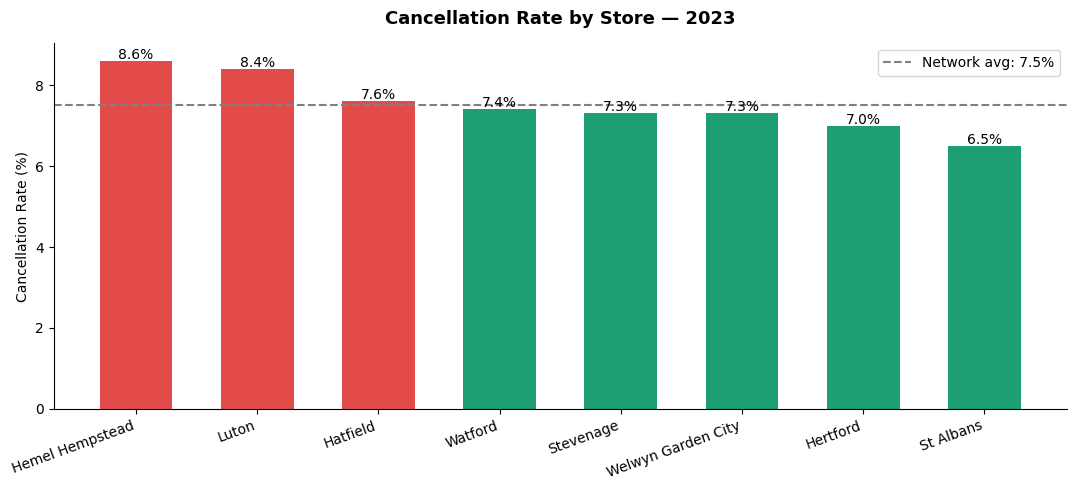

In [15]:
# Same analysis at store level
cancel_store = (
    df.groupby('store_location')
    .agg(
        total     = ('transaction_id', 'count'),
        cancelled = ('status', lambda x: (x == 'Cancelled').sum())
    )
    .reset_index()
)
cancel_store['cancel_rate'] = (cancel_store['cancelled'] / cancel_store['total'] * 100).round(1)
cancel_store = cancel_store.sort_values('cancel_rate', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
avg_s   = cancel_store['cancel_rate'].mean()
colors_s = ['#E24B4A' if r > avg_s else '#1D9E75' for r in cancel_store['cancel_rate']]

bars = ax.bar(cancel_store['store_location'], cancel_store['cancel_rate'],
              color=colors_s, width=0.6)
ax.axhline(avg_s, color='gray', linestyle='--', linewidth=1.5,
           label=f'Network avg: {avg_s:.1f}%')
for bar, val in zip(bars, cancel_store['cancel_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val}%', ha='center', fontsize=10)
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('Cancellation Rate by Store — 2023', fontsize=13, fontweight='bold', pad=14)
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 8. Customer Analysis

Who are the highest-value customers and does Clubcard membership affect spending behaviour?

In [16]:
# Build a customer-level summary
cust = (
    fulfilled_df
    .groupby('customer_id')
    .agg(
        total_spend  = ('total_amount', 'sum'),
        orders       = ('transaction_id', 'count'),
        avg_order    = ('total_amount', 'mean'),
        top_category = ('category', lambda x: x.mode()[0]),
        clubcard     = ('clubcard_member', 'first')
    )
    .reset_index()
    .sort_values('total_spend', ascending=False)
)

# What share of revenue do the top 10% of customers generate?
top10_n   = int(len(cust) * 0.10)
top10_rev = cust.head(top10_n)['total_spend'].sum()
top10_pct = top10_rev / total_revenue * 100

print(f'Total customers:          {len(cust):,}')
print(f'Top 10% ({top10_n:,} customers):  GBP {top10_rev:,.0f}  ({top10_pct:.1f}% of total revenue)')
print(f'\nTop 10 customers by spend:')
print(cust.head(10).round(2).to_string(index=False))

Total customers:          2,972
Top 10% (297 customers):  GBP 16,172  (22.4% of total revenue)

Top 10 customers by spend:
customer_id  total_spend  orders  avg_order  top_category clubcard
   CUST0370        98.35      14       7.02     Household      Yes
   CUST1386        84.72       8      10.59   Meat & Fish       No
   CUST1358        80.77       9       8.97        Frozen      Yes
   CUST2689        80.19       6      13.36       Grocery      Yes
   CUST1154        80.18       7      11.45   Meat & Fish       No
   CUST1711        78.97       9       8.77 Fresh Produce      Yes
   CUST1470        78.83       7      11.26     Household      Yes
   CUST2661        77.77       9       8.64        Frozen      Yes
   CUST0133        76.53       6      12.76        Bakery      Yes
   CUST0604        75.83      10       7.58        Frozen      Yes


Clubcard AOV:     GBP 5.22
Non-Clubcard AOV: GBP 5.15
Uplift:           1.4%


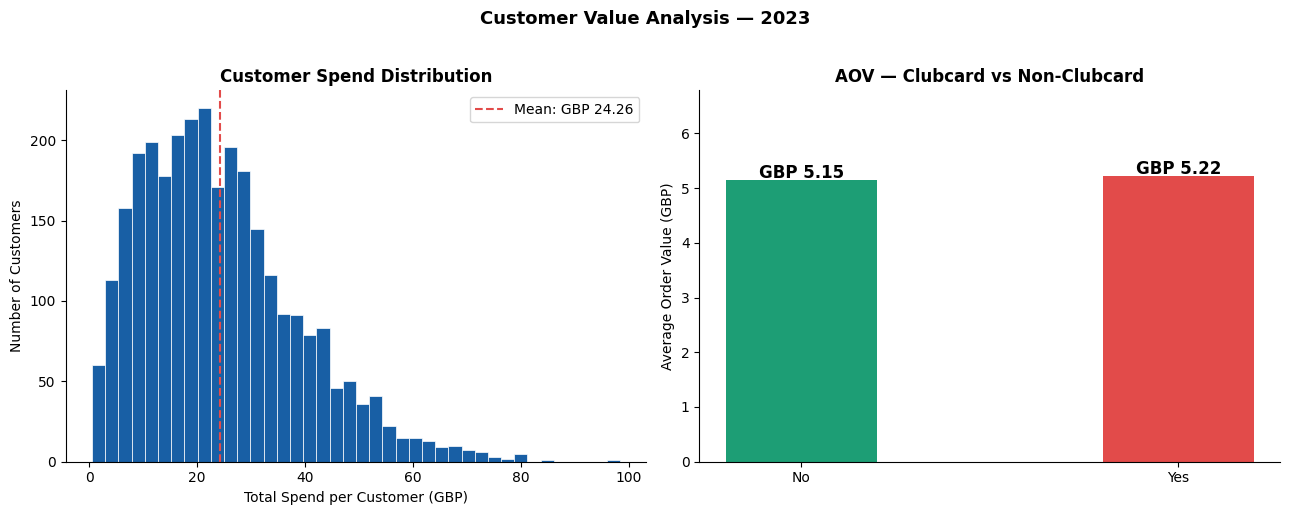

In [17]:
# Compare Clubcard vs non-Clubcard average order value
cc = fulfilled_df.groupby('clubcard_member')['total_amount'].mean().round(2)
uplift = (cc['Yes'] / cc['No'] - 1) * 100

print(f'Clubcard AOV:     GBP {cc["Yes"]:.2f}')
print(f'Non-Clubcard AOV: GBP {cc["No"]:.2f}')
print(f'Uplift:           {uplift:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — spend distribution across all customers
axes[0].hist(cust['total_spend'], bins=40, color='#185FA5', edgecolor='white', linewidth=0.5)
axes[0].axvline(
    cust['total_spend'].mean(), color='#E24B4A',
    linestyle='--', linewidth=1.5,
    label=f'Mean: GBP {cust["total_spend"].mean():.2f}'
)
axes[0].set_xlabel('Total Spend per Customer (GBP)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Spend Distribution', fontweight='bold')
axes[0].legend()

# Right — Clubcard vs non-Clubcard AOV
bar_colors = ['#1D9E75', '#E24B4A']
bars_cc = axes[1].bar(cc.index, cc.values, color=bar_colors, width=0.4)
for bar, val in zip(bars_cc, cc.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, val + 0.03,
        f'GBP {val:.2f}', ha='center', fontsize=12, fontweight='bold'
    )
axes[1].set_ylabel('Average Order Value (GBP)')
axes[1].set_title('AOV — Clubcard vs Non-Clubcard', fontweight='bold')
axes[1].set_ylim(0, max(cc.values) * 1.3)

plt.suptitle('Customer Value Analysis — 2023', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Store Performance

How do the 8 stores compare on revenue, order volume, and cancellation rate?

In [18]:
# Build a store-level summary table
store = (
    fulfilled_df
    .groupby('store_location')
    .agg(
        revenue          = ('total_amount', 'sum'),
        orders           = ('transaction_id', 'count'),
        avg_order        = ('total_amount', 'mean'),
        unique_customers = ('customer_id', 'nunique')
    )
    .reset_index()
)

# Add cancellation rate from the full dataset (not just fulfilled)
store_cancel = (
    df.groupby('store_location')
    .agg(cancel_rate=('status', lambda x: (x == 'Cancelled').sum() / len(x) * 100))
    .reset_index()
)
store = store.merge(store_cancel, on='store_location').sort_values('revenue', ascending=False)
store['avg_order']   = store['avg_order'].round(2)
store['cancel_rate'] = store['cancel_rate'].round(1)

print('Store Performance Summary:')
print(store[['store_location','revenue','orders','avg_order','cancel_rate']].to_string(index=False))

Store Performance Summary:
    store_location  revenue  orders  avg_order  cancel_rate
Welwyn Garden City 14971.73    2826       5.30          7.3
         St Albans 11205.53    2127       5.27          6.5
          Hatfield 11015.33    2091       5.27          7.6
         Stevenage  8740.35    1694       5.16          7.3
             Luton  8571.67    1704       5.03          8.4
           Watford  6966.14    1375       5.07          7.4
   Hemel Hempstead  5560.09    1071       5.19          8.6
          Hertford  5072.63     994       5.10          7.0


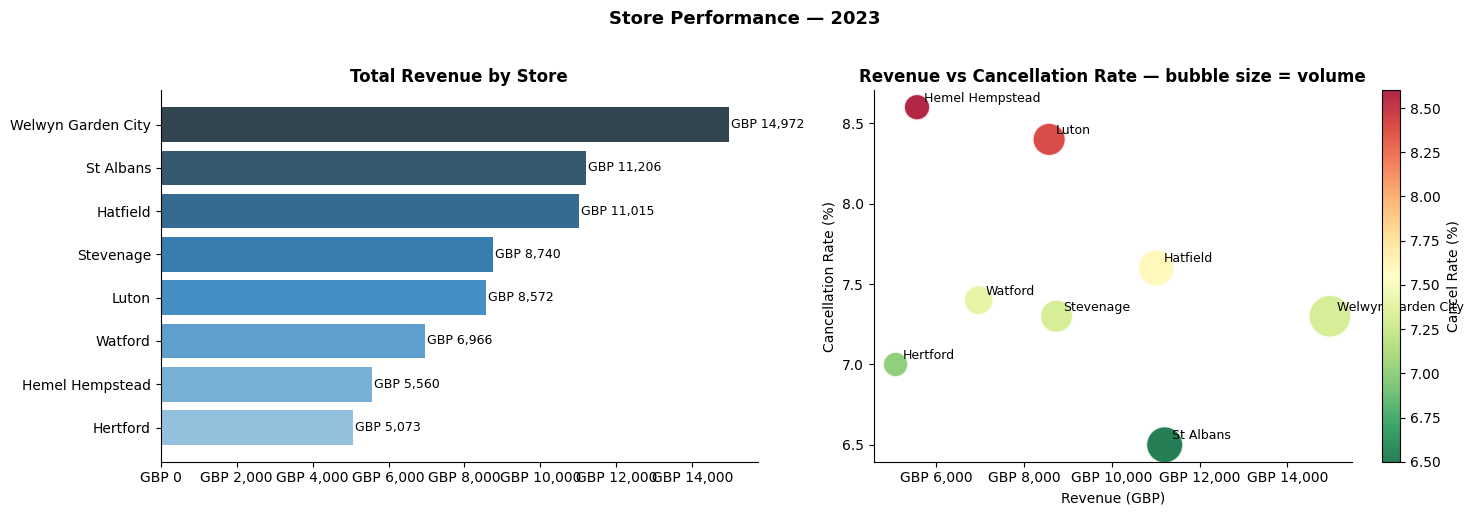

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — revenue bar chart
rev_sorted = store.sort_values('revenue', ascending=True)
axes[0].barh(
    rev_sorted['store_location'], rev_sorted['revenue'],
    color=sns.color_palette('Blues_d', len(rev_sorted))
)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
for i, val in enumerate(rev_sorted['revenue']):
    axes[0].text(val + 50, i, f'GBP {val:,.0f}', va='center', fontsize=9)
axes[0].set_title('Total Revenue by Store', fontweight='bold')

# Right — bubble chart: revenue vs cancel rate, size = order volume
sc = axes[1].scatter(
    store['revenue'], store['cancel_rate'],
    s=store['orders'] / 3,
    c=store['cancel_rate'], cmap='RdYlGn_r',
    alpha=0.85, edgecolors='white', linewidth=1.5
)
for _, row in store.iterrows():
    axes[1].annotate(
        row['store_location'],
        (row['revenue'], row['cancel_rate']),
        textcoords='offset points', xytext=(5, 4), fontsize=9
    )
axes[1].set_xlabel('Revenue (GBP)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_title('Revenue vs Cancellation Rate — bubble size = volume', fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
plt.colorbar(sc, ax=axes[1], label='Cancel Rate (%)')

plt.suptitle('Store Performance — 2023', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Trading Patterns

Weekly revenue trend and day-of-week patterns — useful for operational planning.

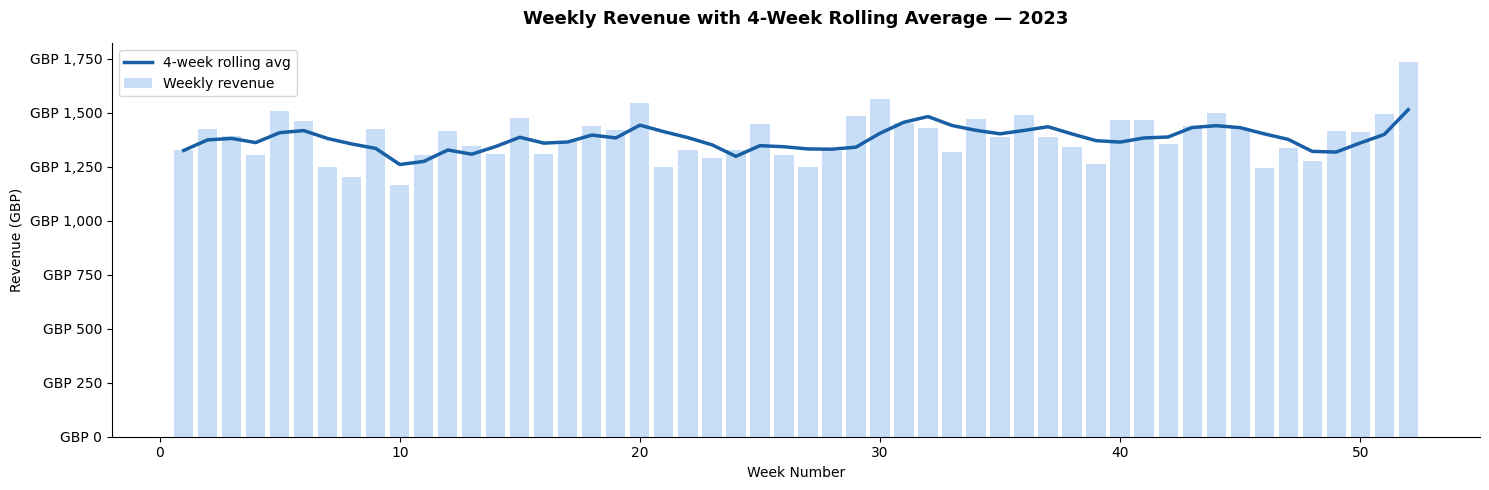

In [20]:
# Weekly revenue — I'll add a 4-week rolling average to smooth out week-to-week noise
weekly = (
    fulfilled_df
    .groupby('week')['total_amount']
    .sum()
    .reset_index()
    .rename(columns={'total_amount': 'revenue'})
)
weekly['rolling_4w'] = weekly['revenue'].rolling(window=4, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(weekly['week'], weekly['revenue'],
       color='#B5D4F4', alpha=0.75, label='Weekly revenue')
ax.plot(weekly['week'], weekly['rolling_4w'],
        color='#185FA5', linewidth=2.5, label='4-week rolling avg')
ax.set_xlabel('Week Number')
ax.set_ylabel('Revenue (GBP)')
ax.set_title('Weekly Revenue with 4-Week Rolling Average — 2023',
             fontsize=13, fontweight='bold', pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

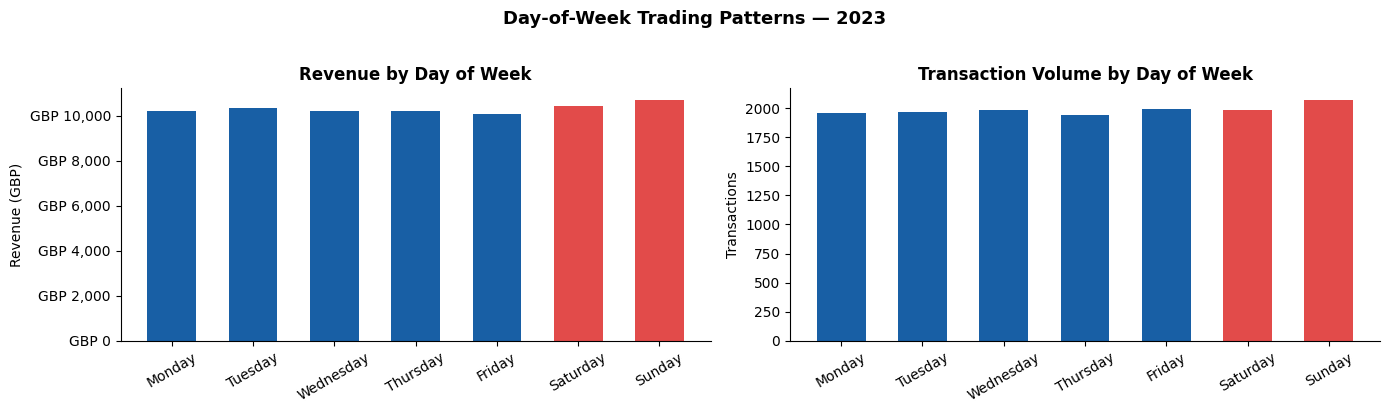

Highest day: Sunday  |  Lowest day: Friday


In [21]:
# Day-of-week patterns — which days trade strongest?
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_rev = (
    fulfilled_df
    .groupby('day_of_week')['total_amount']
    .agg(['sum', 'count'])
    .reindex(day_order)
    .reset_index()
    .rename(columns={'day_of_week':'day', 'sum':'revenue', 'count':'orders'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Highlight weekends in a different colour
colors_d = ['#E24B4A' if d in ['Saturday','Sunday'] else '#185FA5' for d in day_rev['day']]

axes[0].bar(day_rev['day'], day_rev['revenue'], color=colors_d, width=0.6)
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Revenue (GBP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GBP {x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(day_rev['day'], day_rev['orders'], color=colors_d, width=0.6)
axes[1].set_title('Transaction Volume by Day of Week', fontweight='bold')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Day-of-Week Trading Patterns — 2023', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_day  = day_rev.loc[day_rev['revenue'].idxmax(), 'day']
worst_day = day_rev.loc[day_rev['revenue'].idxmin(), 'day']
print(f'Highest day: {best_day}  |  Lowest day: {worst_day}')

## 11. Summary & Recommendations

Pulling together the key findings from each section into prioritised actions.

In [24]:
worst_cat  = cancel_cat.iloc[0]['category']
worst_rate = cancel_cat.iloc[0]['cancel_rate']
total_lost = cancel_cat['est_lost_revenue'].sum()
top_store  = store.iloc[0]['store_location']
top_rev    = store.iloc[0]['revenue']
cc_uplift  = round((cc['Yes'] / cc['No'] - 1) * 100, 1)

print('  FINDINGS & RECOMMENDED ACTIONS')
print()
print('1. REVENUE & SEASONALITY')
print(f'   Full year revenue:   GBP {total_revenue:,.0f}')
print(f'   Peak month:          {best_month} — GBP {monthly_rev[best_month]:,.0f}')
print(f'   Weakest month:       {worst_month} — GBP {monthly_rev[worst_month]:,.0f}')
print('   Action: Begin stock build in October.')
print('           Run promotions in February to lift the weakest period.')
print()
print('2. CANCELLATION RATE')
print(f'   Network rate:        {cancellation_rate:.1f}%')
print(f'   Worst category:      {worst_cat} at {worst_rate}%')
print(f'   Est. revenue lost:   GBP {total_lost:,.0f}')
print('   Action: Audit stock in top 3 cancel categories.')
print('           Automate weekly alert when any category exceeds 10%.')
print()
print('3. CUSTOMER VALUE')
print(f'   Clubcard AOV uplift: {cc_uplift}%')
print('   Action: Target high-value Clubcard customers with')
print('           personalised offers in their top spend category.')
print()
print('4. STORE PERFORMANCE')
print(f'   Top store:           {top_store} — GBP {top_rev:,.0f}')
print('   Action: Share best practices from lowest-cancel')
print('           stores across the network.')
print()

  FINDINGS & RECOMMENDED ACTIONS

1. REVENUE & SEASONALITY
   Full year revenue:   GBP 72,103
   Peak month:          Dec — GBP 6,516
   Weakest month:       Feb — GBP 5,361
   Action: Begin stock build in October.
           Run promotions in February to lift the weakest period.

2. CANCELLATION RATE
   Network rate:        7.5%
   Worst category:      Health & Beauty at 10.0%
   Est. revenue lost:   GBP 0
   Action: Audit stock in top 3 cancel categories.
           Automate weekly alert when any category exceeds 10%.

3. CUSTOMER VALUE
   Clubcard AOV uplift: 1.4%
   Action: Target high-value Clubcard customers with
           personalised offers in their top spend category.

4. STORE PERFORMANCE
   Top store:           Welwyn Garden City — GBP 14,972
   Action: Share best practices from lowest-cancel
           stores across the network.

